In [1]:
import numpy as np
from tqdm import tqdm
from datetime import datetime
import hammingdist
import transmission_functions as tf
from datetime import timedelta
import seaborn as sns
import networkx as nx
from matplotlib import pyplot as plt
from Bio import SeqIO

In [2]:
def create_sequences(n, length = 5, seed = 1234):
    np.random.seed(seed)
    char_list = ['A', 'C', 'T', 'G']
    seq_list = []
    for i in range(n):
        seq_list += [''.join(np.random.choice(['A', 'C', 'T', 'G'], length))]
    return seq_list
n = 1000
seq_list = create_sequences(n)
# seq_list


In [3]:
hammingdist_list = []
for i in range(n):
    hammingdist_list += [hammingdist.distance(seq_list[0], seq_list[i])]
hammingdist_list

# Simulate datediff matrix:
gmean = 4.87
gsd = 1.98
a = gmean**2 / gsd**2
b = gsd**2 / gmean 
datediffs = np.random.gamma(a, b, size = (n, n)).astype(int)

total_days_epidemic = 31
date_choices = [datetime(2021, 1, 1) + timedelta(i)for i in range(total_days_epidemic)]
sample_dates = np.random.choice(date_choices, n)

datediffs = np.zeros((n, n)).astype(int)
for i, dt in tqdm(enumerate(sample_dates)):
    for j in range(i):
        datediffs[i, j] = (sample_dates[i] - sample_dates[j]).days
            # datediffs should be anti-symmetric
        datediffs[j, i] = - datediffs[i, j]

hamming_mat = np.zeros((n, n))
for i in tqdm(range(n)):
    for j in range(n):
        if i==j:
            continue
        else:
            hamming_mat[i, j] = hammingdist.distance(seq_list[i], seq_list[j])


1000it [00:00, 4831.90it/s]
100%|██████████| 1000/1000 [00:00<00:00, 3084.01it/s]


In [4]:
import Bio
seq_record_list = []
seq_ids = []
for i in range(len(seq_list)):
    seq_ids += ['sequence_' + str(i)]
    seq_record_list += [Bio.SeqRecord.SeqRecord(Bio.Seq.Seq(seq_list[i]), id = seq_ids[i])]


In [5]:
sequences = seq_record_list 
with open("../data/demo_sequences.fasta", "w") as output_handle:
    SeqIO.write(sequences, output_handle, "fasta")

In [6]:
reweight_zero = 0
shift_sensitivity = 0
low_sr = False
# Max number of days - 21 is a decent cutoff to make transmission >21 days unlikely
ndays = 20 + 1
# Max number of substitutions - 9 is a decent cutoff to make transmission >9 substitutions unlikely. In practice, limit is 2
nsubs = 9
# Substitution rate - subject to sensitivity! On average 1 mutation per 11 days.
if low_sr:
    sr = 0.06
else:
    sr = 1/11
    
days = np.arange(ndays)
subs = np.arange(nsubs)
# prob_mat is a matrix whose (i, j)th entry is the probability that a transmission pair (A, B) has i days between testing and a Hamming distance of j.
prob_mat = np.zeros((ndays, nsubs+1))

for sub in range(nsubs+1):
    for d, day in enumerate(days):

        prob = tf.scenario1_probability(day, sub, sr, shift = shift_sensitivity)
        prob_mat[d, sub] = prob
prob_mat = prob_mat.T
if reweight_zero:
    prob_mat += 5e-6
    prob_mat /= np.sum(prob_mat)

In [7]:
def weighted_adj_mat_2(hamming_mat, daydiff_mat, idxs, prob_mat = prob_mat):
    new_dist = hamming_mat.astype(int)
    new_dates = daydiff_mat.astype(int)
    
    valid_distances = [v for (v, d) in idxs]
    valid_daydiffs = [d for (v, d) in idxs]

    invalid_distances = ~np.isin(new_dist, valid_distances)
    invalid_daydiffs =  ~np.isin(new_dates, valid_daydiffs)

    invalid_idxs = invalid_daydiffs + invalid_distances
    weighted_mat = prob_mat[new_dist*(1-invalid_idxs), new_dates*(1-invalid_idxs)]
    np.fill_diagonal(weighted_mat, 0)
    weighted_mat[invalid_idxs] = 0
    return weighted_mat

# Get indices of probability space corresponding to plausible transmission via a Poisson process, based on prob_mat
def get_idxs(ndays = 20 + 1,
            nsubs = 9,
            sr = sr, 
            shift = 0):

    days = np.arange(ndays)
    subs = np.arange(nsubs)
    prob_mat = np.zeros((ndays, nsubs+1))
    for sub in range(nsubs+1):
        for d, day in enumerate(days):

            prob = tf.scenario1_probability(day, sub, sr)
            prob_mat[d, sub] = prob
        # prob_mats += [prob_mat]
    prob_mat = prob_mat.T
    time = np.arange(21)
    cprob = (np.cumsum(tf.gamma_probability_discrete(time)))
    p_cutoff = 0.95
    t_cutoff = time[np.argwhere(cprob > p_cutoff)[0][0]]
    prob_mat_cutoff = np.zeros_like(prob_mat)
    all_subs = np.arange(10)
    inhomogeneous = False
    tdiff1 = 6

    for sub in range(nsubs+1):

        for d, day in enumerate(days):
            cprob_sub = (np.sum(tf.substitution_probability(all_subs[:sub+1], d, sr, inhomogeneous=inhomogeneous)))
            cprob_day = (np.sum(tf.gamma_probability_discrete(time[:d+1], shift = shift)))
            

            prob_mat_cutoff[sub, d] = (int(cprob_sub <= p_cutoff) * int(d <=t_cutoff))
    valid_idxs = [(0, 0)] + list(zip(*np.where(prob_mat_cutoff == 1)))
    return valid_idxs


valid_idxs = get_idxs(shift = shift_sensitivity)


In [8]:
import polars as pl
import pandas as pd
pd.DataFrame(np.vstack((seq_ids, sample_dates)).T, columns = ['strain', 'SampleDateTime']).to_csv('../data/demo_sample_dates.csv')
pd.read_csv('../data/demo_sample_dates.csv', index_col = [0])
pd.DataFrame(seq_ids, columns = ['strain']).to_csv('../data/demo_ids.csv')

In [9]:
tree_adj_mat = weighted_adj_mat_2(hamming_mat, datediffs, valid_idxs, prob_mat)

<Axes: ylabel='Count'>

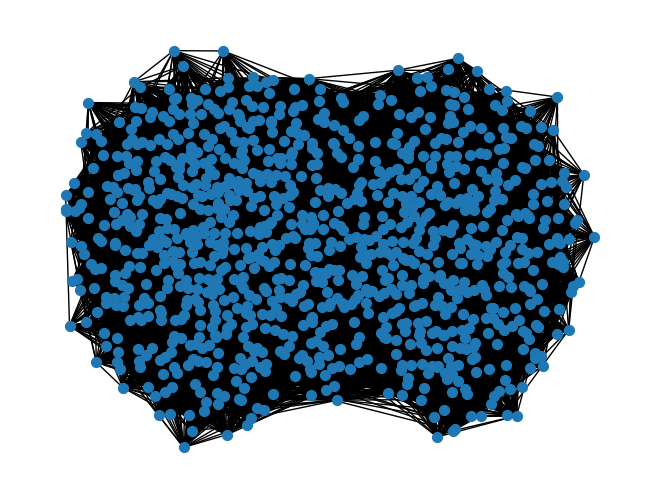

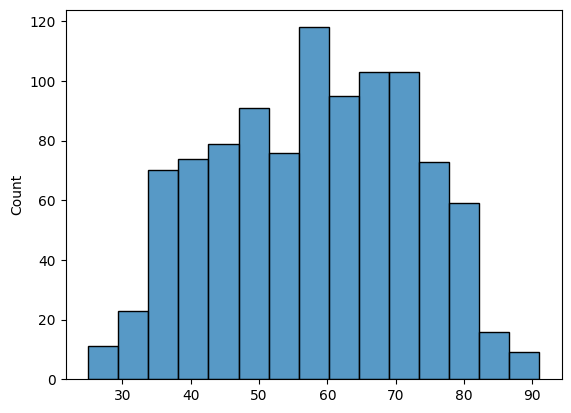

In [10]:
import networkx as nx
G = nx.from_numpy_array(tree_adj_mat)
nx.draw(G, node_size=50)
plt.figure()
sns.histplot([val for key, val in G.degree()])

Text(0.5, 1.0, 'Generation Time Distribution')

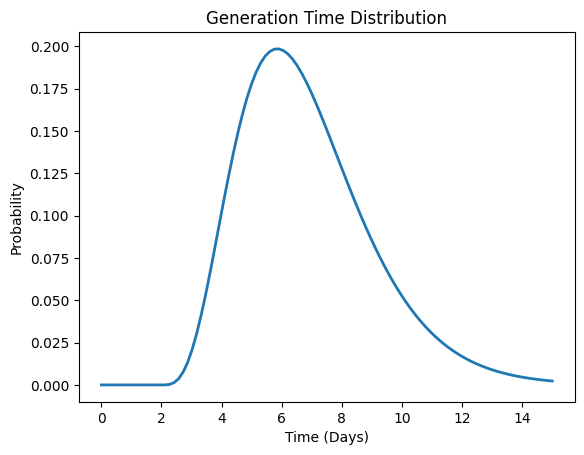

In [11]:
import scipy as sp
plt.plot(np.linspace(0, 15, 100), sp.stats.gamma.pdf( np.linspace(0, 15, 100), 4.87, 1.98), linewidth = 2)
plt.xlabel('Time (Days)')
plt.ylabel('Probability')
plt.title('Generation Time Distribution')

In [12]:
np.random.seed(1234)
random_family_edges = [(u, v) for i, (u, v) in enumerate(G.edges()) if i in 
                       np.random.choice(np.arange(len(G.edges())), 100).astype(int)]


In [13]:
pd.DataFrame(random_family_edges, columns = ['PERSON_ID_1', 'PERSON_ID_2']).to_csv('../data/demo_family_edgelist.csv')

In [14]:
np.random.seed(1234)
p_school = 0.05
p_work = 0.075
households_vec = np.random.choice(['address_' + str(i) for i in range(int(n/3))], n)
schools_vec = np.random.choice(['school_A', 'school_B', 'school_C', np.nan], 
                               size = n, p = np.array((p_school, p_school, p_school, 1-3*p_school)))
workplace_vec = np.random.choice(['workplace_A', 'workplace_B', 'workplace_C', np.nan], 
                               size = n, p = np.array((p_work, p_work, p_work, 1-3*p_work)))

person_ids_vec = np.arange(n).astype(int)
school_types_vec = np.zeros(n).astype(int).astype(str)
school_types_vec[schools_vec == 'school_A'] = 'Grundskole'
school_types_vec[(schools_vec == 'school_B') | (schools_vec == 'school_C')] = 'Gymnasiale uddannelser'
school_types_vec[school_types_vec == '0'] = np.nan

kommune_vec = np.ones(n).astype(int)
region_vec = np.ones(n).astype(int)



# Vacc attributes: 
first_vacc_vec = np.random.choice(np.array((True, False)).astype(int), size = n, p = np.array((0.8, 0.2)))
days_since_first_vac = np.nan * np.ones(n)
days_since_first_vac[first_vacc_vec == 1] = np.random.choice(np.arange(60).astype(int), size = len(days_since_first_vac[first_vacc_vec == 1]))

second_vacc_vec = np.random.choice(np.array((True, False)).astype(int), size = n, 
                                   p = np.array((0.7, 0.3))) * first_vacc_vec
days_since_second_vac = np.nan * np.ones(n)
days_since_second_vac[second_vacc_vec == 1] = np.random.choice(np.arange(60).astype(int), size = len(days_since_second_vac[second_vacc_vec == 1]))


third_vacc_vec = np.random.choice(np.array((True, False)).astype(int), size = n, 
                                   p = np.array((0.7, 0.3))) * second_vacc_vec
days_since_third_vac = np.nan * np.ones(n)
days_since_third_vac[third_vacc_vec == 1] = np.random.choice(np.arange(60).astype(int), size = len(days_since_third_vac[third_vacc_vec == 1]))

age_at_testing = np.random.choice(np.arange(80).astype(int), size = n)
df_mat = np.vstack((np.array(seq_ids), person_ids_vec, age_at_testing, sample_dates, households_vec, kommune_vec,
                     kommune_vec, region_vec, region_vec, schools_vec, school_types_vec, workplace_vec,
                    days_since_second_vac, second_vacc_vec, days_since_first_vac,first_vacc_vec, days_since_third_vac, third_vacc_vec))

df_cols = ['strain', 'PERSON_ID', 'Age_at_testing', 'SampleDateTime','UNIQUE_ADDRESS_ID', 'KOMMUNE_NAME', 'KOM',
           'Region', 'Regionskode','UDD_ID', 'school_type', 'ARB_NR', 'Days_since_complete_vaccination',
            'Complete_vaccination_before_sampling', 'Days_since_first_vaccination', 
            'First_vaccination_before_sampling', 'Days_since_third_vaccination', 'Third_vaccination_before_sampling']
pd.DataFrame(df_mat.T, columns = df_cols).to_csv('../data/all_attributes.csv')

In [15]:
school_types = np.array((('school_A', 'Grundskole'), ('school_B', 'Gymnasiale uddannelser'), ('school_C', 'Gymnasiale uddannelser')))
pl.DataFrame(school_types, schema = ['school', 'school_type']).write_csv('../data/school_types.csv')

## Dummy data for running the negative binomial model:

Make serial interval file with entries Rt_adj, Rt_adj_0.975, Rt_adj_0.025, iar_0.5, iar_0.975, iar_0.025

In [16]:
import scipy as sp
total_days_epidemic = 31
rt_len = 31

proportion_of_pcrpositives_sequenced = pd.DataFrame(np.vstack((date_choices, 
                                                               0.8 * np.ones(total_days_epidemic))).T)
proportion_of_pcrpositives_sequenced.to_csv('../data/proportion_of_pcrpositives_sequenced.csv')

rt_iar = np.ones(total_days_epidemic)
rt_iar[:15] = 0.5
rt_iar[15:] = 0.8

serial_interval = pl.DataFrame(sp.stats.gamma.pdf( np.arange(100), 4.87, 1.98).T, schema = ['fit'])
np.savetxt('../data/serial_interval.csv', serial_interval)

Rt_adj = (1.2  + 0.1* np.linspace(1, 10, rt_len))
Rt_adj_0_025 = (1.1 + 0.1* np.linspace(1, 10, rt_len))
Rt_adj_0_975 = (1.3 + 0.1* np.linspace(1, 10, rt_len))

iar_0_5 = 0.8 * np.ones(rt_len)
iar_0_975 = 0.9 * np.ones(rt_len)
iar_0_025 = 0.7 * np.ones(rt_len)

rt_iar_file = pl.DataFrame(np.vstack((Rt_adj, 
            Rt_adj_0_025, 
            Rt_adj_0_975, 
            iar_0_5, 
            iar_0_025, 
            iar_0_975)).T).rename({'column_0' : 'Rt_adj', 
                                   'column_1' : 'Rt_adj_0.025', 
                                   'column_2' : 'Rt_adj_0.975', 
                                   'column_3' : 'iar_0.5', 
                                   'column_4' : 'iar_0.025', 
                                   'column_5' : 'iar_0.975'})

rt_iar_file.with_columns(date = pl.Series(date_choices).cast(pl.Date)).write_csv('../data/rt_iar.csv')
